# 🤖 Superstore – 5 Bước Training AI Dự báo Lợi nhuận
---
| Mục | Nội dung |
|---|---|
| **Dataset** | `Superstore_clean.csv` – 9,994 đơn hàng (2011–2014) |
| **Target** | `Profit` (Lợi nhuận) |
| **Mô hình** | **Gradient Boosting Regressor** |
| **Split** | **80% Train / 20% Test** |
| **CV** | 5-Fold Cross-Validation (hiện kết quả từng fold) |
| **Output** | Dự báo Profit 3 tháng tới |

> Pipeline chuẩn 5 bước: **Thu thập → Tiền xử lý → Huấn luyện → Đánh giá → Dự báo**


## ⚙️ Import thư viện

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
PALETTE = {'navy':'#1b365d','teal':'#008080','red':'#d9534f',
           'gold':'#e8a838','grey':'#6c757d'}
print("Import hoan tat!")


Import hoan tat!


---
## 📂 BƯỚC 1 – Thu thập & Tiền xử lý Dữ liệu
*(Data Collection & Preprocessing)*


In [2]:
# 1.1 Đọc dữ liệu
DATA_PATH = '../data/Superstore_clean.csv'
df_raw = pd.read_csv(DATA_PATH)
df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'], dayfirst=False)
print(f"Shape goc: {df_raw.shape[0]:,} dong x {df_raw.shape[1]} cot")
print(f"Khoang thoi gian: {df_raw['Order Date'].min().date()} -> {df_raw['Order Date'].max().date()}")
df_raw.head(3)


Shape goc: 9,994 dong x 26 cot
Khoang thoi gian: 2011-01-04 -> 2014-12-31


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Ship Lead Time (Days),Profit Status,Year,Month,Quarter
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,3,Profit,2013,11,4
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,3,Profit,2013,11,4
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,4,Profit,2013,6,2


In [3]:
# 1.2 Thống kê & Kiểm tra Missing
print("=== BANG THONG KE DU LIEU GOC ===")
display(df_raw[['Sales','Discount','Quantity','Profit']].describe().round(2))

missing = df_raw.isnull().sum()
total_missing = missing.sum()
if total_missing == 0:
    print("\nKhong co missing values!")
else:
    display(pd.DataFrame({'Missing': missing[missing > 0]}))


=== BANG THONG KE DU LIEU GOC ===


,Sales,Discount,Quantity,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,0.16,3.79,28.66
std,623.25,0.21,2.23,234.26
min,0.44,0.00,1.00,-6599.98
25%,17.28,0.00,2.00,1.73
50%,54.49,0.20,3.00,8.67
75%,209.94,0.20,5.00,29.36
max,22638.48,0.80,14.00,8399.98



Khong co missing values!


In [4]:
# 1.3 Chọn features & Preprocessing Pipeline
FEATURES     = ['Sales', 'Discount', 'Quantity', 'Category', 'Region']
TARGET       = 'Profit'
NUMERIC_FEAT = ['Sales', 'Discount', 'Quantity']
CAT_FEAT     = ['Category', 'Region']

df = df_raw[FEATURES + [TARGET, 'Order Date']].dropna().copy()
df.sort_values('Order Date', inplace=True)
df.reset_index(drop=True, inplace=True)

X = df[FEATURES].copy()
y = df[TARGET].values

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEAT),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEAT),
], remainder='drop')

print("=== BANG TOM TAT PREPROCESSING ===")
display(pd.DataFrame({
    'Thanh phan'     : ['Tong mau', 'Features dau vao', 'Features so', 'Features phan loai (OHE)', 'Target'],
    'Gia tri'        : [f"{len(df):,}", ', '.join(FEATURES), ', '.join(NUMERIC_FEAT), ', '.join(CAT_FEAT), TARGET],
    'Xu ly'          : ['—', '—', 'StandardScaler', 'OneHotEncoder', '—'],
}))


=== BANG TOM TAT PREPROCESSING ===


,Thanh phan,Gia tri,Xu ly
0,Tong mau,"9,994",—
1,Features dau vao,"Sales, Discount, Quantity, Category, Region",—
2,Features so,"Sales, Discount, Quantity",StandardScaler
3,Features phan loai (OHE),"Category, Region",OneHotEncoder
4,Target,Profit,—


---
## ✂️ BƯỚC 2 – Chia tập Train / Test (80% / 20%)
*(Train-Test Split)*

> **80%** dữ liệu để mô hình học — **20%** để kiểm tra.  
> Dùng `shuffle=False` để giữ nguyên thứ tự thời gian (tránh data leakage).


=== BANG CHIA DU LIEU TRAIN / TEST ===


,Tap du lieu,So mau,Ti le,Khoang thoi gian
0,Train (Hoc),7995,80%,2011-01-04 -> 2014-07-19
1,Test (Thi),1999,20%,2014-07-19 -> 2014-12-31
2,Tong,9994,100%,2011-01-04 -> 2014-12-31


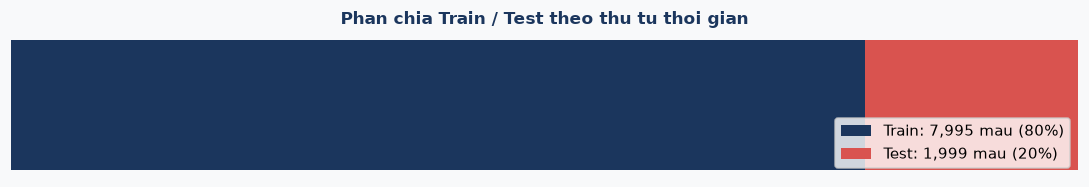

Train: 7,995 mau | Test: 1,999 mau


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

split_df = pd.DataFrame({
    'Tap du lieu'     : ['Train (Hoc)', 'Test (Thi)', 'Tong'],
    'So mau'          : [len(X_train), len(X_test), len(X)],
    'Ti le'           : ['80%', '20%', '100%'],
    'Khoang thoi gian': [
        f"{df['Order Date'].iloc[0].date()} -> {df['Order Date'].iloc[len(X_train)-1].date()}",
        f"{df['Order Date'].iloc[len(X_train)].date()} -> {df['Order Date'].iloc[-1].date()}",
        f"{df['Order Date'].iloc[0].date()} -> {df['Order Date'].iloc[-1].date()}"
    ]
})
print("=== BANG CHIA DU LIEU TRAIN / TEST ===")
display(split_df)

fig, ax = plt.subplots(figsize=(10, 1.8), facecolor='#f8f9fa')
ax.barh(0, len(X_train), color=PALETTE['navy'], height=0.5, label=f'Train: {len(X_train):,} mau (80%)')
ax.barh(0, len(X_test),  left=len(X_train), color=PALETTE['red'], height=0.5, label=f'Test: {len(X_test):,} mau (20%)')
ax.set_xlim(0, len(X)); ax.axis('off')
ax.legend(loc='lower right', fontsize=10)
ax.set_title('Phan chia Train / Test theo thu tu thoi gian', fontweight='bold', fontsize=11, color=PALETTE['navy'])
plt.tight_layout(); plt.show()
print(f"Train: {len(X_train):,} mau | Test: {len(X_test):,} mau")


---
## 🏋️ BƯỚC 3 – Huấn luyện Mô hình Gradient Boosting (5-Fold CV)
*(Model Training)*

> **5-Fold Cross-Validation trên tập Train**: Chia Train thành 5 phần — mỗi vòng dùng 4 phần học, 1 phần kiểm tra nội bộ.  
> Mục đích: Đánh giá độ ổn định mô hình qua **5 vòng lặp** trước khi thi thật.


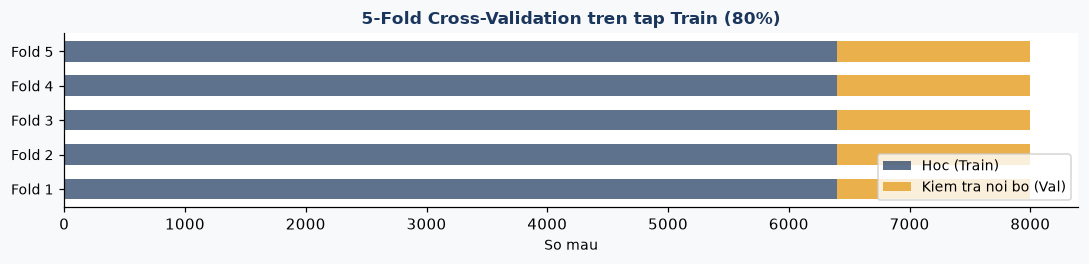

In [6]:
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=False)

# Minh hoạ cấu trúc 5-Fold
fig, ax = plt.subplots(figsize=(10, 2.5), facecolor='#f8f9fa')
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    ax.barh(fold, len(tr_idx), color=PALETTE['navy'], alpha=0.7, height=0.6,
            label='Hoc (Train)' if fold==0 else '')
    ax.barh(fold, len(val_idx), left=len(tr_idx), color=PALETTE['gold'],
            alpha=0.9, height=0.6, label='Kiem tra noi bo (Val)' if fold==0 else '')
ax.set_yticks(range(N_FOLDS))
ax.set_yticklabels([f'Fold {i+1}' for i in range(N_FOLDS)], fontsize=9)
ax.set_xlabel('So mau', fontsize=9)
ax.set_title('5-Fold Cross-Validation tren tap Train (80%)',
             fontweight='bold', fontsize=11, color=PALETTE['navy'])
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


In [7]:
# ── Gradient Boosting – Kết quả TỪNG FOLD ──
MODEL_NAME = 'Gradient Boosting'
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                      max_depth=5, subsample=0.8, random_state=42)
pipe = Pipeline([('prep', preprocessor), ('model', gb_model)])

fold_records = []
print(f"{'='*60}")
print(f"  Mo hinh: {MODEL_NAME}")
print(f"{'='*60}")
print(f"  {'Fold':<6} {'Train MAE':>11} {'Val MAE':>11} {'Val RMSE':>11} {'Val R2':>8}")
print(f"  {'-'*52}")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), start=1):
    Xtr,  ytr  = X_train.iloc[tr_idx],  y_train[tr_idx]
    Xval, yval = X_train.iloc[val_idx], y_train[val_idx]

    pipe.fit(Xtr, ytr)
    pred_tr  = pipe.predict(Xtr)
    pred_val = pipe.predict(Xval)

    tr_mae   = mean_absolute_error(ytr, pred_tr)
    val_mae  = mean_absolute_error(yval, pred_val)
    val_rmse = np.sqrt(mean_squared_error(yval, pred_val))
    val_r2   = r2_score(yval, pred_val)

    fold_records.append({
        'Vong lap (Fold)' : f'Fold {fold}',
        'Train MAE ($)'   : round(tr_mae, 2),
        'Val MAE ($)'     : round(val_mae, 2),
        'Val RMSE ($)'    : round(val_rmse, 2),
        'Val R2 Score'    : round(val_r2, 4)
    })
    print(f"  Fold {fold}  {tr_mae:>11.2f} {val_mae:>11.2f} {val_rmse:>11.2f} {val_r2:>8.4f}")

fold_df = pd.DataFrame(fold_records)
avg = {
    'Vong lap (Fold)' : 'TRUNG BINH',
    'Train MAE ($)'   : fold_df['Train MAE ($)'].mean().round(2),
    'Val MAE ($)'     : fold_df['Val MAE ($)'].mean().round(2),
    'Val RMSE ($)'    : fold_df['Val RMSE ($)'].mean().round(2),
    'Val R2 Score'    : fold_df['Val R2 Score'].mean().round(4)
}
fold_df = pd.concat([fold_df, pd.DataFrame([avg])], ignore_index=True)

print(f"  {'-'*52}")
print(f"  Avg   {avg['Train MAE ($)']:>11.2f} {avg['Val MAE ($)']:>11.2f} "
      f"{avg['Val RMSE ($)']:>11.2f} {avg['Val R2 Score']:>8.4f}")
print(f"\n=== BANG KET QUA TUNG FOLD – GRADIENT BOOSTING ===")
display(fold_df)


  Mo hinh: Gradient Boosting
  Fold     Train MAE     Val MAE    Val RMSE   Val R2
  ----------------------------------------------------


  Fold 1        16.59       33.31      268.62  -0.6811


  Fold 2        17.02       24.76       82.35   0.7901


  Fold 3        17.24       29.19      132.11   0.5472


  Fold 4        17.19       27.23      171.44   0.6746


  Fold 5        17.47       24.82       71.03   0.9282
  ----------------------------------------------------
  Avg         17.10       27.86      145.11   0.4518

=== BANG KET QUA TUNG FOLD – GRADIENT BOOSTING ===


,Vong lap (Fold),Train MAE ($),Val MAE ($),Val RMSE ($),Val R2 Score
0,Fold 1,16.59,33.31,268.62,-0.6811
1,Fold 2,17.02,24.76,82.35,0.7901
2,Fold 3,17.24,29.19,132.11,0.5472
3,Fold 4,17.19,27.23,171.44,0.6746
4,Fold 5,17.47,24.82,71.03,0.9282
5,TRUNG BINH,17.10,27.86,145.11,0.4518


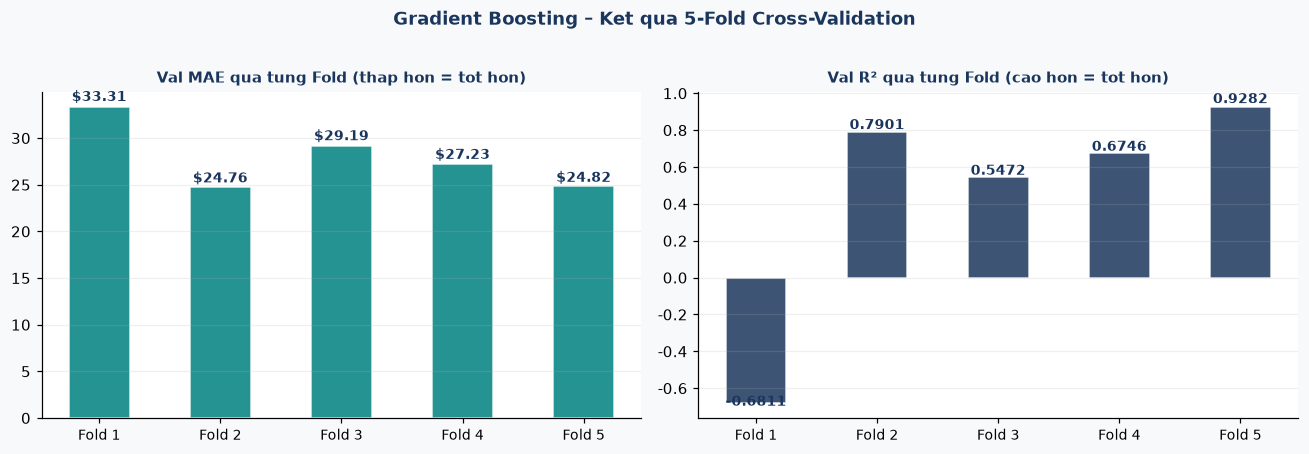

In [8]:
# Biểu đồ MAE & R2 theo từng Fold
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), facecolor='#f8f9fa')
folds_only = fold_df[fold_df['Vong lap (Fold)'] != 'TRUNG BINH'].copy()
folds_labels = folds_only['Vong lap (Fold)'].tolist()
xs = range(len(folds_labels))

for ax, col, title, color in [
    (ax1, 'Val MAE ($)', 'Val MAE qua tung Fold (thap hon = tot hon)', PALETTE['teal']),
    (ax2, 'Val R2 Score', 'Val R² qua tung Fold (cao hon = tot hon)', PALETTE['navy'])
]:
    vals = folds_only[col].tolist()
    bars = ax.bar(xs, vals, color=color, width=0.5, edgecolor='white', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{v:.4f}' if col=='Val R2 Score' else f'${v:,.2f}',
                ha='center', fontsize=9, fontweight='bold', color=PALETTE['navy'])
    ax.set_xticks(xs); ax.set_xticklabels(folds_labels, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10, color=PALETTE['navy'])
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle(f'Gradient Boosting – Ket qua 5-Fold Cross-Validation',
             fontweight='bold', fontsize=12, color=PALETTE['navy'], y=1.02)
plt.tight_layout(); plt.show()


---
## 📊 BƯỚC 4 – Đánh giá Mô hình trên tập Test (20%)
*(Model Evaluation)*

> Đây là bài **"thi"** thật sự — mô hình gặp dữ liệu chưa thấy bao giờ.


In [9]:
# Re-train trên toàn bộ 80% Train, rồi test trên 20%
pipe.fit(X_train, y_train)
pred_test = pipe.predict(X_test)

test_mae  = mean_absolute_error(y_test, pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
test_r2   = r2_score(y_test, pred_test)

cv_mae  = avg['Val MAE ($)']
cv_rmse = avg['Val RMSE ($)']
cv_r2   = avg['Val R2 Score']

# Bảng so sánh CV vs Test
eval_df = pd.DataFrame({
    'Chi so'          : ['MAE ($)', 'RMSE ($)', 'R2 Score'],
    'Luc hoc - CV'    : [f"${cv_mae:,.2f}", f"${cv_rmse:,.2f}", f"{cv_r2:.4f}"],
    'Luc thi - Test'  : [f"${test_mae:,.2f}", f"${test_rmse:,.2f}", f"{test_r2:.4f}"],
    'Nhan xet'        : [
        'Tot hon (+)' if test_mae < cv_mae else 'Kem hon (-)',
        'Tot hon (+)' if test_rmse < cv_rmse else 'Kem hon (-)',
        'Tot hon (+)' if test_r2 > cv_r2 else 'Kem hon (-)'
    ]
})
print("=== BANG DANH GIA: LUC HOC (CV) VS LUC THI (TEST) ===")
display(eval_df)

print(f"\nKet qua Gradient Boosting tren tap Test (20%):")
print(f"  MAE  = ${test_mae:,.2f}  (sai so trung binh moi don hang)")
print(f"  RMSE = ${test_rmse:,.2f}")
print(f"  R2   = {test_r2:.4f}  (mo hinh giai thich {test_r2*100:.1f}% phuong sai Profit)")


=== BANG DANH GIA: LUC HOC (CV) VS LUC THI (TEST) ===


,Chi so,Luc hoc - CV,Luc thi - Test,Nhan xet
0,MAE ($),$27.86,$25.77,Tot hon (+)
1,RMSE ($),$145.11,$110.16,Tot hon (+)
2,R2 Score,0.4518,0.7785,Tot hon (+)



Ket qua Gradient Boosting tren tap Test (20%):
  MAE  = $25.77  (sai so trung binh moi don hang)
  RMSE = $110.16
  R2   = 0.7785  (mo hinh giai thich 77.9% phuong sai Profit)


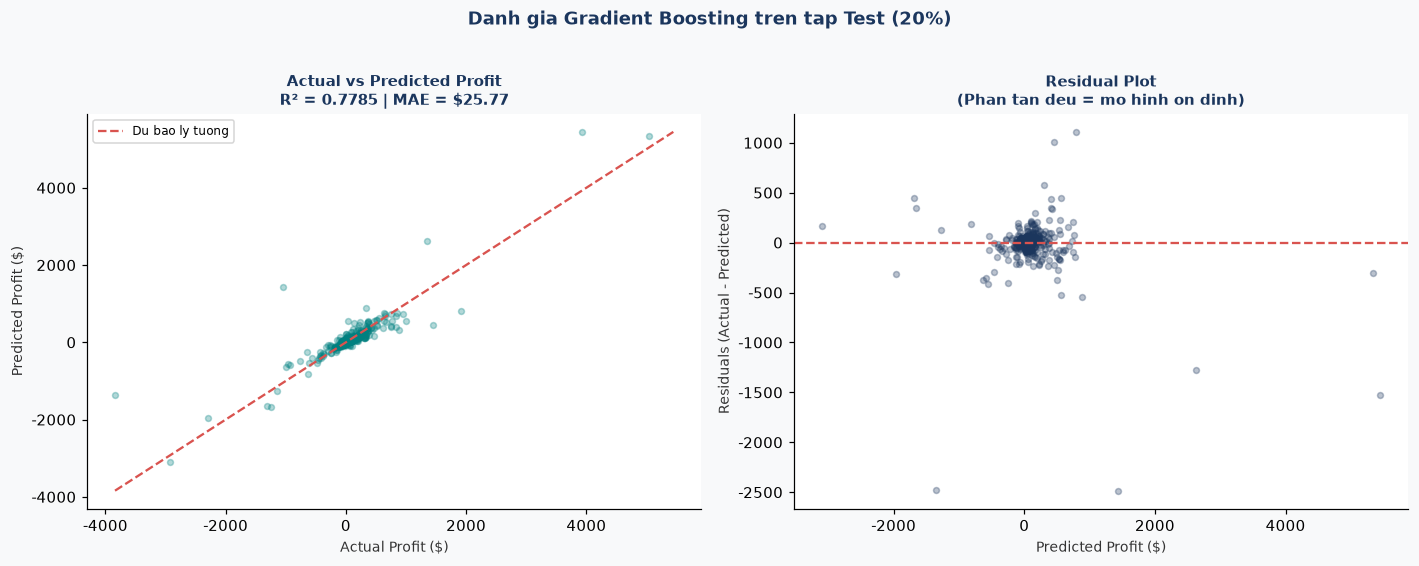

In [10]:
# Biểu đồ: Actual vs Predicted + Residuals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), facecolor='#f8f9fa')

# Panel 1: Actual vs Predicted
ax1.scatter(y_test, pred_test, alpha=0.3, color=PALETTE['teal'], s=15)
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax1.plot(lims, lims, color=PALETTE['red'], lw=1.5, linestyle='--', label='Du bao ly tuong')
ax1.set_xlabel('Actual Profit ($)', fontsize=9, color='#333333')
ax1.set_ylabel('Predicted Profit ($)', fontsize=9, color='#333333')
ax1.set_title(f'Actual vs Predicted Profit\nR² = {test_r2:.4f} | MAE = ${test_mae:,.2f}',
              fontweight='bold', fontsize=10, color=PALETTE['navy'])
ax1.legend(fontsize=8)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Panel 2: Residuals
residuals = y_test - pred_test
ax2.scatter(pred_test, residuals, alpha=0.3, color=PALETTE['navy'], s=15)
ax2.axhline(0, color=PALETTE['red'], lw=1.5, linestyle='--')
ax2.set_xlabel('Predicted Profit ($)', fontsize=9, color='#333333')
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=9, color='#333333')
ax2.set_title('Residual Plot\n(Phan tan deu = mo hinh on dinh)',
              fontweight='bold', fontsize=10, color=PALETTE['navy'])
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Danh gia Gradient Boosting tren tap Test (20%)',
             fontweight='bold', fontsize=12, color=PALETTE['navy'], y=1.02)
plt.tight_layout(); plt.show()


In [11]:
# BÁO CÁO ĐỘ CHÍNH XÁC AI ĐÃ LUYỆN TẬP & THI
actual_mean = abs(y_test).mean()
acc_pct_cv   = max(0, 100 - (cv_mae / actual_mean * 100))
acc_pct_test = max(0, 100 - (test_mae / actual_mean * 100))

acc_df = pd.DataFrame({
    'Giai doan'               : ['Luc HOC (5-Fold CV)', 'Luc THI (Test 20%)'],
    'Mo hinh'                 : ['Gradient Boosting', 'Gradient Boosting'],
    'R2 Score (%)'            : [f"{cv_r2*100:.2f}%", f"{test_r2*100:.2f}%"],
    'Do chinh xac tuong doi (%)': [f"{acc_pct_cv:.2f}%", f"{acc_pct_test:.2f}%"],
    'Sai so MAE ($)'          : [f"${cv_mae:,.2f}", f"${test_mae:,.2f}"],
    'Sai so RMSE ($)'         : [f"${cv_rmse:,.2f}", f"${test_rmse:,.2f}"],
})

print("=== BAO CAO DO CHINH XAC AI DA LUYEN TAP & THI ===")
display(acc_df)

print(f"\nTOM TAT DO CHINH XAC MO HINH GRADIENT BOOSTING:")
print(f"  Luc HOC (CV)  – R2: {cv_r2*100:.2f}%  | Do chinh xac: {acc_pct_cv:.2f}%  | MAE: ${cv_mae:,.2f}")
print(f"  Luc THI (Test)– R2: {test_r2*100:.2f}%  | Do chinh xac: {acc_pct_test:.2f}%  | MAE: ${test_mae:,.2f}")


=== BAO CAO DO CHINH XAC AI DA LUYEN TAP & THI ===


,Giai doan,Mo hinh,R2 Score (%),Do chinh xac tuong doi (%),Sai so MAE ($),Sai so RMSE ($)
0,Luc HOC (5-Fold CV),Gradient Boosting,45.18%,55.45%,$27.86,$145.11
1,Luc THI (Test 20%),Gradient Boosting,77.85%,58.79%,$25.77,$110.16



TOM TAT DO CHINH XAC MO HINH GRADIENT BOOSTING:
  Luc HOC (CV)  – R2: 45.18%  | Do chinh xac: 55.45%  | MAE: $27.86
  Luc THI (Test)– R2: 77.85%  | Do chinh xac: 58.79%  | MAE: $25.77


---
## 🔮 BƯỚC 5 – Dự báo Profit 3 tháng tới
*(Prediction & Deployment)*


In [12]:
# Re-train trên 100% dữ liệu (Train + Test)
pipe.fit(X, y)

# Tính tốc độ tăng trưởng
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('YearMonth').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()
monthly['YM_str'] = monthly['YearMonth'].astype(str)

growth_rate      = max(0.0, monthly['Sales'].pct_change().dropna().tail(12).mean())
base_month_sales = monthly['Sales'].iloc[-1]
cat_share = df.groupby('Category')['Sales'].sum() / df['Sales'].sum()
reg_share  = df.groupby('Region')['Sales'].sum()  / df['Sales'].sum()

last_date       = df['Order Date'].max()
future_periods  = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=3, freq='MS')
forecast_labels = [p.strftime('%Y-%m') for p in future_periods]

def forecast_month(idx):
    month_sales = base_month_sales * (1 + growth_rate) ** idx
    rows = []
    for cat in cat_share.index:
        for reg in reg_share.index:
            seg  = month_sales * cat_share[cat] * reg_share[reg]
            mask = (df['Category']==cat) & (df['Region']==reg)
            aov  = df.loc[mask,'Sales'].mean()
            n    = max(1, round(seg / aov))
            rows.append({'Sales': seg/n, 'Discount': df.loc[mask,'Discount'].mean(),
                         'Quantity': df.loc[mask,'Quantity'].mean(),
                         'Category': cat, 'Region': reg, '_n': n})
    sdf    = pd.DataFrame(rows)
    profit = float((pipe.predict(sdf[FEATURES]) * sdf['_n'].values).sum())
    return {'Thang': forecast_labels[idx-1], 'Sales': month_sales,
            'Profit': profit, 'Margin': profit/month_sales*100}

fc_raw = [forecast_month(m) for m in range(1, 4)]

print("=== BANG DU BAO PROFIT 3 THANG TOI ===")
fc_disp = pd.DataFrame([{
    'Thang'              : r['Thang'],
    'Doanh thu uoc tinh' : f"${r['Sales']:,.0f}",
    'Loi nhuan uoc tinh' : f"${r['Profit']:,.0f}",
    'Bien LN (%)'        : f"{r['Margin']:.1f}%",
    'So thang truoc'     : ('—' if i==0 else
                            f"{(r['Profit']-fc_raw[i-1]['Profit'])/fc_raw[i-1]['Profit']*100:+.1f}%")
} for i, r in enumerate(fc_raw)])
display(fc_disp)


=== BANG DU BAO PROFIT 3 THANG TOI ===


,Thang,Doanh thu uoc tinh,Loi nhuan uoc tinh,Bien LN (%),So thang truoc
0,2015-01,"$100,761","$10,198",10.1%,—
1,2015-02,"$112,217","$11,387",10.1%,+11.7%
2,2015-03,"$124,975","$12,578",10.1%,+10.5%


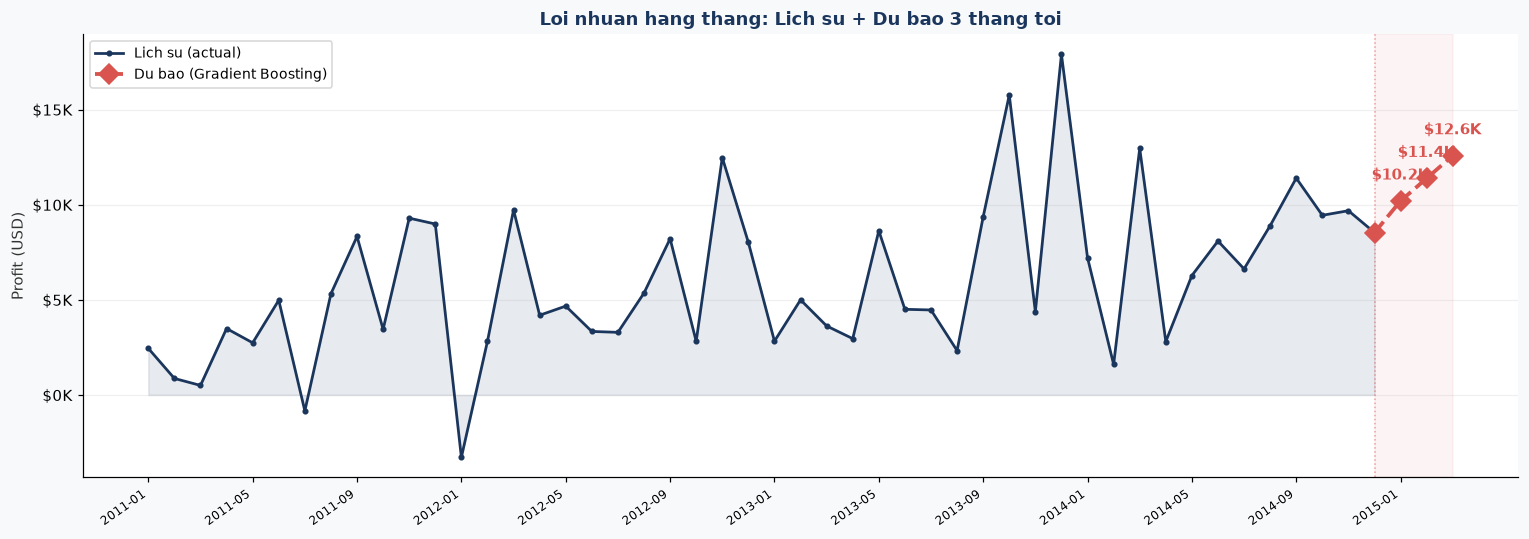

In [13]:
# Biểu đồ: Lịch sử + Dự báo 3 tháng
hist_profits = monthly['Profit'].tolist()
hist_labels  = monthly['YM_str'].tolist()
fc_profits   = [r['Profit'] for r in fc_raw]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#f8f9fa')
xs = range(len(hist_profits))
ax.fill_between(xs, hist_profits, alpha=0.1, color=PALETTE['navy'])
ax.plot(xs, hist_profits, color=PALETTE['navy'], lw=1.8, marker='o', ms=3, label='Lich su (actual)')

xs_fc   = range(len(hist_profits)-1, len(hist_profits)+3)
connect = [hist_profits[-1]] + fc_profits
ax.plot(xs_fc, connect, color=PALETTE['red'], lw=2.5, marker='D', ms=9,
        linestyle='--', label='Du bao (Gradient Boosting)', zorder=5)

for xp, vp in zip(list(xs_fc)[1:], fc_profits):
    ax.annotate(f'${vp/1e3:.1f}K', (xp, vp),
                textcoords='offset points', xytext=(0, 14),
                ha='center', fontsize=10, fontweight='bold', color=PALETTE['red'])

ax.axvspan(len(hist_profits)-1, len(hist_profits)+2, alpha=0.06, color=PALETTE['red'])
ax.axvline(x=len(hist_profits)-1, color=PALETTE['red'], lw=1, linestyle=':', alpha=0.5)

all_labels = hist_labels + forecast_labels
step = max(1, len(all_labels)//12)
ax.set_xticks(range(0, len(all_labels), step))
ax.set_xticklabels([all_labels[i] for i in range(0, len(all_labels), step)],
                   rotation=35, ha='right', fontsize=8)
ax.set_title('Loi nhuan hang thang: Lich su + Du bao 3 thang toi',
             fontweight='bold', fontsize=12, color=PALETTE['navy'])
ax.set_ylabel('Profit (USD)', fontsize=10, color='#333333')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax.legend(fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()


---
## 📋 Tổng kết – Báo cáo 5 Bước

In [14]:
print("=" * 65)
print("  TONG KET 5 BUOC TRAINING AI – GRADIENT BOOSTING")
print("=" * 65)

steps_info = [
    ("Buoc 1", "Thu thap & Tien xu ly",
     f"{len(df):,} mau · 5 features · StandardScaler + OHE"),
    ("Buoc 2", "Chia Train/Test 80/20",
     f"Train: {len(X_train):,} mau | Test: {len(X_test):,} mau"),
    ("Buoc 3", "Huan luyen Gradient Boosting (5-Fold CV)",
     f"5 vong lap | Val R2 trung binh: {cv_r2*100:.2f}%"),
    ("Buoc 4", "Danh gia tren Test",
     f"MAE=${test_mae:,.2f} | RMSE=${test_rmse:,.2f} | R2={test_r2:.4f}"),
    ("Buoc 5", "Du bao 3 thang toi",
     " | ".join([f"{r['Thang']}: ${r['Profit']:,.0f}" for r in fc_raw])),
]
for step, title, detail in steps_info:
    print(f"\n  {step} – {title}")
    print(f"     -> {detail}")
print("\n" + "=" * 65)

display(pd.DataFrame([{'Buoc': s, 'Noi dung': t, 'Ket qua': d}
                      for s, t, d in steps_info]))


  TONG KET 5 BUOC TRAINING AI – GRADIENT BOOSTING

  Buoc 1 – Thu thap & Tien xu ly
     -> 9,994 mau · 5 features · StandardScaler + OHE

  Buoc 2 – Chia Train/Test 80/20
     -> Train: 7,995 mau | Test: 1,999 mau

  Buoc 3 – Huan luyen Gradient Boosting (5-Fold CV)
     -> 5 vong lap | Val R2 trung binh: 45.18%

  Buoc 4 – Danh gia tren Test
     -> MAE=$25.77 | RMSE=$110.16 | R2=0.7785

  Buoc 5 – Du bao 3 thang toi
     -> 2015-01: $10,198 | 2015-02: $11,387 | 2015-03: $12,578



,Buoc,Noi dung,Ket qua
0,Buoc 1,Thu thap & Tien xu ly,"9,994 mau · 5 features · StandardScaler + OHE"
1,Buoc 2,Chia Train/Test 80/20,"Train: 7,995 mau | Test: 1,999 mau"
2,Buoc 3,Huan luyen Gradient Boosting (5-Fold CV),5 vong lap | Val R2 trung binh: 45.18%
3,Buoc 4,Danh gia tren Test,MAE=$25.77 | RMSE=$110.16 | R2=0.7785
4,Buoc 5,Du bao 3 thang toi,"2015-01: $10,198 | 2015-02: $11,387 | 2015-03:..."
